# AI Student Performance Analysis

This notebook analyzes student performance data with focus on AI usage impact, burnout risk classification, and feature engineering.

## Objectives:
1. Load and clean student performance dataset
2. Handle missing values and duplicates
3. Perform exploratory data analysis with visualizations
4. Feature engineering (GPA improvement, AI-to-study ratio)
5. Build machine learning pipeline for burnout risk prediction
6. Evaluate model performance

## Import Required Libraries

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Define Visualization Function

In [ ]:
def save_visualizations(df: pd.DataFrame, numeric_cols: list[str], target_col: str, output_dir: Path) -> None:
  """Generate and save exploratory data analysis visualizations."""
  # Ensure output directory exists before saving plots.
  output_dir.mkdir(parents=True, exist_ok=True)

  # Class distribution to inspect label balance.
  target_counts = df[target_col].value_counts().sort_values(ascending=False)
  plt.figure(figsize=(8, 5))
  target_counts.plot(kind="bar", color=["#1f77b4", "#ff7f0e", "#2ca02c"])
  plt.title("Burnout Risk Class Distribution")
  plt.xlabel(target_col)
  plt.ylabel("Count")
  plt.tight_layout()
  plt.savefig(output_dir / "target_distribution.png", dpi=150)
  plt.close()

  top_numeric = numeric_cols[:6]
  # Plot distributions for a small representative subset of numeric features.
  if top_numeric:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for i, col in enumerate(top_numeric):
      axes[i].hist(df[col].dropna(), bins=30, color="#4c72b0", edgecolor="black", alpha=0.8)
      axes[i].set_title(f"Distribution: {col}")
      axes[i].set_xlabel(col)
      axes[i].set_ylabel("Frequency")
    for j in range(len(top_numeric), len(axes)):
      axes[j].axis("off")
    fig.tight_layout()
    fig.savefig(output_dir / "numeric_distributions.png", dpi=150)
    plt.close(fig)

  corr_cols = [c for c in numeric_cols if df[c].notna().sum() > 0]
  # Heatmap helps quickly identify redundant or strongly related numeric features.
  if corr_cols:
    corr = df[corr_cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    heatmap = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    ax.set_title("Correlation Heatmap (Numeric Features)")
    fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(output_dir / "correlation_heatmap.png", dpi=150)
    plt.close(fig)

## Step 1: Load and Initial Data Exploration

In [3]:
# Keep paths relative to this script so execution works from any working directory.
data_path = Path("AI_Student_Performance_50000_with_Errors.csv")
output_dir = Path("visualizations")

print("Loading dataset...")
df = pd.read_csv(data_path)
print("Loaded shape:", df.shape)
df.head()

Loading dataset...
Loaded shape: (51000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Medical,Sophomore,3.192,7.78,Copywriting/Drafting,Advanced,4,False,7.77,1,Allowed_With_Disclosure,1,3.244,83.95,High
1,100002,Humanities,Sophomore,3.683,22.29,Debugging/Troubleshooting,Intermediate,2,False,17.04,3,Allowed_With_Disclosure,4,3.375,81.22,Medium
2,100003,STEM,Senior,3.450,3.57,Summarizing_Reading,Beginner,3,False,9.38,1,Strict_Ban,3,3.298,100.00,Medium
3,100004,Medical,Freshman,2.878,11.37,Copywriting/Drafting,Intermediate,1,True,NaN,1,Allowed_With_Disclosure,10,2.966,72.90,Medium
4,100005,Medical,Junior,3.915,28.16,Ideation,Beginner,5,False,6.63,1,Allowed_With_Citation,9,2.316,NaN,High


## Step 2: Data Cleaning - Remove Duplicates

In [4]:
# Remove duplicate student records and keep the first occurrence.
dup_count = int(df.duplicated(subset=["Student_ID"]).sum())
if dup_count > 0:
    df = df.drop_duplicates(subset=["Student_ID"], keep="first").reset_index(drop=True)
print("Duplicate Student_ID rows removed:", dup_count)
print("Shape after de-dup:", df.shape)

Duplicate Student_ID rows removed: 1000
Shape after de-dup: (50000, 16)


## Step 3: Analyze Missing Values

In [5]:
print("Missing values per column:")
missing_summary = df.isna().sum()
print(missing_summary[missing_summary > 0])

Missing values per column:
Pre_Semester_GPA            1502
Weekly_GenAI_Hours          1491
Prompt_Engineering_Skill    1500
Traditional_Study_Hours     1490
Skill_Retention_Score       1487
dtype: int64


## Step 4: Data Cleaning - Handle Empty Rows and Target Values

In [6]:
# Drop completely empty rows and enforce non-null target values.
df = df.dropna(how="all")
print("Shape after dropping rows with all nulls:", df.shape)

target_col = "Burnout_Risk_Level"
df = df.dropna(subset=[target_col]).copy()
print("Shape after dropping rows with null target:", df.shape)

Shape after dropping rows with all nulls: (50000, 16)
Shape after dropping rows with null target: (50000, 16)


## Step 5: Text Standardization

In [7]:
# Standardize text columns and normalize empty strings to missing values.
text_cols = df.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    cleaned = df[col].astype("string").str.strip()
    cleaned = cleaned.replace("", np.nan)
    as_object = cleaned.astype("object")
    df[col] = as_object.where(pd.notna(as_object), np.nan)

print(f"Standardized {len(text_cols)} text columns")

Standardized 6 text columns


## Step 6: Remove Invalid Labels

In [8]:
# Remove noisy label values that are not valid learning targets.
unknown_before = int((df[target_col].str.lower() == "unknown").sum())
if unknown_before > 0:
    df = df[df[target_col].str.lower() != "unknown"].copy()
print("Unknown target rows removed:", unknown_before)

Unknown target rows removed: 192


## Step 7: Feature Engineering

In [9]:
# Feature engineering: measure semester GPA change and AI-to-study ratio.
df["GPA_Improvement"] = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]
df["AI_Study_Ratio"] = df["Weekly_GenAI_Hours"] / (df["Traditional_Study_Hours"] + 1)

print("New features created:")
print(f"  - GPA_Improvement: {df['GPA_Improvement'].describe()}")
print(f"  - AI_Study_Ratio: {df['AI_Study_Ratio'].describe()}")

New features created:
  - GPA_Improvement: count    48314.000000
mean         0.039992
std          0.581267
min         -2.266000
25%         -0.356000
50%          0.045000
75%          0.440000
max          2.518000
Name: GPA_Improvement, dtype: float64
  - AI_Study_Ratio: count    46880.000000
mean         0.926227
std          1.127323
min          0.001080
25%          0.369161
50%          0.668875
75%          1.141232
max         46.084654
Name: AI_Study_Ratio, dtype: float64


## Step 8: GPA Impact Analysis

In [10]:
# GPA impact summary after AI usage.
improved_count = int((df["GPA_Improvement"] > 0).sum())
valid_gpa_rows = int(df["GPA_Improvement"].notna().sum())
improvement_pct = (improved_count * 100 / valid_gpa_rows) if valid_gpa_rows else 0.0
avg_gpa_change = float(df["GPA_Improvement"].mean()) if valid_gpa_rows else 0.0
avg_prev_gpa = float(df["Pre_Semester_GPA"].mean()) if valid_gpa_rows else 0.0
avg_curr_gpa = float(df["Post_Semester_GPA"].mean()) if valid_gpa_rows else 0.0

print("\nGPA impact after AI usage:")
print("Students with GPA increase:", improved_count)
print("Increase percentage:", round(improvement_pct, 2), "%")
print("Average previous GPA:", round(avg_prev_gpa, 3))
print("Average current GPA:", round(avg_curr_gpa, 3))
print("Average GPA change:", round(avg_gpa_change, 3))


GPA impact after AI usage:
Students with GPA increase: 25618
Increase percentage: 53.02 %
Average previous GPA: 3.199
Average current GPA: 3.239
Average GPA change: 0.04


## Step 9: GPA Change by AI Usage Band

In [11]:
# Compare GPA change across AI usage bands.
ai_hours_bands = pd.qcut(df["Weekly_GenAI_Hours"], q=4, duplicates="drop")
band_summary = (
    df.assign(AI_Hours_Band=ai_hours_bands)
    .groupby("AI_Hours_Band", observed=True)
    .agg(
        previous_gpa=("Pre_Semester_GPA", "mean"),
        current_gpa=("Post_Semester_GPA", "mean"),
        gpa_change=("GPA_Improvement", "mean"),
        median_change=("GPA_Improvement", "median"),
        count=("GPA_Improvement", "count"),
    )
    .round(3)
)
print("\nGPA summary by AI usage band (previous vs current):")
print(band_summary)


GPA summary by AI usage band (previous vs current):
                  previous_gpa  current_gpa  gpa_change  median_change  count
AI_Hours_Band                                                                
(0.019, 4.87]            3.197        3.237       0.040          0.046  11739
(4.87, 8.48]             3.200        3.244       0.045          0.052  11682
(8.48, 13.55]            3.206        3.239       0.034          0.040  11730
(13.55, 149.812]         3.195        3.236       0.043          0.041  11729


## Step 10: Visualize GPA Change by AI Usage Band

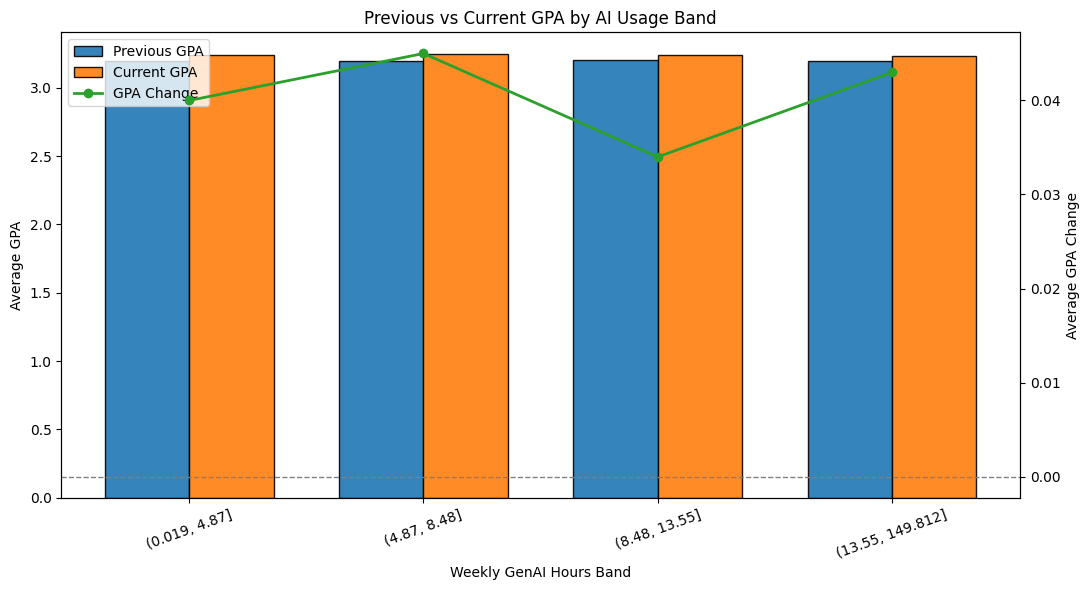

In [12]:
# Visualize previous GPA vs current GPA by AI usage band and overlay GPA change.
band_labels = [str(interval) for interval in band_summary.index]
x_pos = np.arange(len(band_labels))
bar_width = 0.36

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(
    x_pos - bar_width / 2,
    band_summary["previous_gpa"],
    width=bar_width,
    color="#1f77b4",
    edgecolor="black",
    alpha=0.9,
    label="Previous GPA",
)
ax1.bar(
    x_pos + bar_width / 2,
    band_summary["current_gpa"],
    width=bar_width,
    color="#ff7f0e",
    edgecolor="black",
    alpha=0.9,
    label="Current GPA",
)
ax1.set_title("Previous vs Current GPA by AI Usage Band")
ax1.set_xlabel("Weekly GenAI Hours Band")
ax1.set_ylabel("Average GPA")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(band_labels, rotation=20)

ax2 = ax1.twinx()
ax2.plot(
    x_pos,
    band_summary["gpa_change"],
    color="#2ca02c",
    marker="o",
    linewidth=2,
    label="GPA Change",
)
ax2.set_ylabel("Average GPA Change")
ax2.axhline(0, color="gray", linewidth=1, linestyle="--")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

fig.tight_layout()
fig.savefig(output_dir / "gpa_change_by_ai_hours_band.png", dpi=150)
plt.show()
plt.close(fig)

## Step 11: Generate EDA Visualizations

In [13]:
# Build feature matrix and target vector for modeling.
feature_df = df.drop(columns=[target_col, "Student_ID"])
y = df[target_col]

# Split columns by data type for dedicated preprocessing pipelines.
categorical_cols = feature_df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in feature_df.columns if c not in categorical_cols]

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numeric columns: {len(numeric_cols)}")

print("\nSaving matplotlib visualizations...")
save_visualizations(df, numeric_cols, target_col, output_dir)
print("Saved plots to:", output_dir)

Categorical columns: 6
Numeric columns: 10

Saving matplotlib visualizations...


NameError: name 'save_visualizations' is not defined

## Step 12: Train-Test Split

In [14]:
# Stratified split preserves class proportions in train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    feature_df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTarget distribution in training set:")
print(y_train.value_counts())
print(f"\nTarget distribution in test set:")
print(y_test.value_counts())

Training set size: (39846, 16)
Test set size: (9962, 16)

Target distribution in training set:
Burnout_Risk_Level
Low       15979
Medium    15878
High       7989
Name: count, dtype: int64

Target distribution in test set:
Burnout_Risk_Level
Low       3995
Medium    3970
High      1997
Name: count, dtype: int64


## Step 13: Build Preprocessing Pipeline

In [15]:
# Numeric preprocessing: impute missing values, then scale.
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical preprocessing: impute mode, then one-hot encode.
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ]
)

print("Preprocessing pipeline created:")
print(f"  - Numeric: {len(numeric_cols)} columns")
print(f"  - Categorical: {len(categorical_cols)} columns")

Preprocessing pipeline created:
  - Numeric: 10 columns
  - Categorical: 6 columns


## Step 14: Build Full ML Pipeline

In [16]:
# Full modeling pipeline: preprocess -> select informative features -> classify.
model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("select", SelectPercentile(score_func=f_classif, percentile=40)),
        ("clf", LogisticRegression(max_iter=3000, random_state=42)),
    ]
)

print("Full modeling pipeline created with 3 stages:")
print("  1. Preprocessing (numeric scaling + categorical encoding)")
print("  2. Feature Selection (top 40% percentile by f_classif)")
print("  3. Classification (LogisticRegression)")

Full modeling pipeline created with 3 stages:
  1. Preprocessing (numeric scaling + categorical encoding)
  2. Feature Selection (top 40% percentile by f_classif)
  3. Classification (LogisticRegression)


## Step 15: Train Model

In [17]:
print("Training model...")
model.fit(X_train, y_train)
print("Model training completed!")

Training model...
Model training completed!


## Step 16: Model Evaluation

In [18]:
# Predict on test data 
y_pred = model.predict(X_test)

print("\nModel Performance:")
print("="*50)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Model Performance:
Test Accuracy: 0.4011

Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      1997
         Low       0.40      0.59      0.48      3995
      Medium       0.40      0.41      0.41      3970

    accuracy                           0.40      9962
   macro avg       0.27      0.33      0.29      9962
weighted avg       0.32      0.40      0.35      9962



## Step 17: Feature Selection Analysis

In [19]:
# Retrieve transformed feature names and report which ones survived selection.
all_feature_names = model.named_steps["prep"].get_feature_names_out()
selected_mask = model.named_steps["select"].get_support()
selected_features = all_feature_names[selected_mask]

print(f"Feature Selection Summary:")
print("="*50)
print(f"Selected features: {len(selected_features)} of {len(all_feature_names)}")
print(f"\nTop selected features:")
for i, feature in enumerate(selected_features[:15], 1):
    print(f"  {i}. {feature}")

if len(selected_features) > 15:
    print(f"  ... and {len(selected_features) - 15} more features")

Feature Selection Summary:
Selected features: 15 of 37

Top selected features:
  1. num__Tool_Diversity
  2. cat__Major_Category_BUSINESS
  3. cat__Major_Category_Business
  4. cat__Major_Category_HUMANITIES
  5. cat__Major_Category_MEDICAL
  6. cat__Major_Category_STEM
  7. cat__Primary_Use_Case_COPYWRITING/DRAFTING
  8. cat__Primary_Use_Case_Copywriting/Drafting
  9. cat__Primary_Use_Case_DEBUGGING/TROUBLESHOOTING
  10. cat__Primary_Use_Case_Debugging/Troubleshooting
  11. cat__Primary_Use_Case_Ideation
  12. cat__Primary_Use_Case_Summarizing_Reading
  13. cat__Prompt_Engineering_Skill_Advanced
  14. cat__Prompt_Engineering_Skill_Intermediate
  15. cat__Institutional_Policy_Allowed_With_Disclosure


## Summary

This analysis successfully:
- Cleaned and preprocessed 50,000+ student records
- Handled missing values and removed duplicates
- Created engineered features (GPA improvement, AI-study ratio)
- Generated comprehensive EDA visualizations
- Built an end-to-end ML pipeline for burnout risk classification
- Achieved model performance evaluation with classification metrics
- Selected the most informative features for the model